In [149]:
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_groq import ChatGroq
from pydantic import BaseModel, Field
from typing import TypedDict, Literal, Annotated
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
import operator

In [150]:
load_dotenv()

True

In [ ]:
generator_llm = ChatGroq(
    model = "openai/gpt-oss-20b"
)

evaluator_llm = ChatGroq(
    model = "openai/gpt-oss-120b"
)

optimizer_llm = ChatGroq(
    model = "openai/gpt-oss-120b"
)

In [152]:
class TweetState(TypedDict):
    topic : str
    tweet : str
    evaluation : Literal['approved','needs_imporvement']
    feedback : str
    iterations : int
    max_iterations : int 
    
    tweet_history : Annotated[list[str], operator.add]
    feedback_history : Annotated[list[str], operator.add]

In [153]:
class Evaluation(BaseModel):
    evaluation : Literal['approved','needs_improvement'] = Field(...,description = "This represents whether the tweet is approved for posting or not.")
    feedback : str = Field(...,description = "Constructive feedback of the tweet post.")
    
structured_evaluator_llm = evaluator_llm.with_structured_output(Evaluation)

In [154]:
def generate_tweet(state : TweetState):
    
    # Prompt
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
            Write a short, original, and hilarious tweet on the topic: "{state['topic']}".
            Rules:
            - Do NOT use question-answer format.
            - Max 280 characters.
            - Use observational humor, irony, sarcasm, or cultural references.
            - Think in meme logic, punchlines, or relatable takes.
            - Use simple, day to day english
            """
        )
    ]
    
    # Send to generator
    response = generator_llm.invoke(messages).content
    
    return {'tweet':response,'tweet_history':[response]}

def evaluate_tweet(state : TweetState):
    
    # Prompt    
    messages = [
        SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
        HumanMessage(content=f"""
            Evaluate the following tweet:

            Tweet: "{state['tweet' ]}"

            Use the criteria below to evaluate the tweet:

            1. Originality - Is this fresh, or have you seen it a hundred times before?
            2. Humor - Did it genuinely make you smile, laugh, or chuckle?
            3. Punchiness - Is it short, sharp, and scroll-stopping?
            4. Virality Potential - Would people retweet or share it?
            5. Format - Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

            Auto-reject if:
            It's written in question-answer format (e.g., "Why did ... " or "What happens when ... ")
            It exceeds 280 characters
            It reads like a traditional setup-punchline joke
            Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., "Masterpieces of the auntie-uncle
            universe" or vague summaries)

            ### Respond ONLY in structured format:
            - evaluation: "approved" or "needs improvement"
            - feedback: One paragraph explaining the strengths and weaknesses
            """
            )
        ] 
    
    # Send to evaluator
    response = structured_evaluator_llm.invoke(messages)
    
    return {"evaluation":response.evaluation, "feedback":response.feedback,"feedback_history":[response.feedback]}

def optimize_tweet(state : TweetState):
    
    # Prompt
    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
            Improve the tweet based on this feedback:
            "{state['feedback' ]}"
            
            Topic: "{state['topic' ]}"
            Original Tweet:
            {state['tweet' ]},
            
            Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters."""
        )
    ]
    
    # Send to Optimizer
    response = optimizer_llm.invoke(messages).content
    iteration = state['iterations'] + 1
    
    return {"tweet":response,"iterations":iteration,"tweet_history":[response]}

def route_evaluation(state : TweetState):
    if state['evaluation'] == 'approved' or state['iterations'] >= state['max_iterations']:
        return 'approved'
    else:
        return 'needs_improvement'

In [155]:
graph = StateGraph(TweetState)

graph.add_node("generation",generate_tweet)
graph.add_node("evaluation",evaluate_tweet)
graph.add_node("optimization",optimize_tweet)

graph.add_edge(START,'generation')
graph.add_edge('generation','evaluation')

graph.add_conditional_edges('evaluation',route_evaluation, {'approved':END,'needs_improvement':'optimization'})

graph.add_edge('optimization','evaluation')

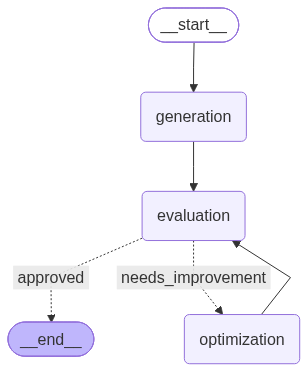

In [156]:
workflow = graph.compile()
workflow

In [158]:
initial_state = {
    "topic": "hfjskw",
    "iterations": 1,
    "max_iterations": 5
}
result = workflow.invoke(initial_state)

result

HfHubHTTPError: Client error '402 Payment Required' for url 'https://router.huggingface.co/v1/chat/completions' (Request ID: Root=1-6a89db09-52c2e9034a0fb5d8084161da;55248593-7d0f-4738-8cdc-860788e35261)
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/402

You have depleted your monthly included credits. Purchase pre-paid credits to continue using Inference Providers. Alternatively, subscribe to PRO to get 20x more included usage.